In [19]:
!pip install -q --upgrade scikit-learn==1.7.2 scikeras==0.13.0

In [1]:
import tensorflow as tf
import keras
import sklearn
import scikeras

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("scikit-learn :", sklearn.__version__)
print("SciKeras :", scikeras.__version__)

TensorFlow : 2.20.0
Keras      : 3.13.2
scikit-learn : 1.7.2
SciKeras : 0.13.0


# Task 1: Dataset Exploration

## Objective
To load the Fashion-MNIST dataset, examine its structure, visualize sample images, and analyze the class distribution before training the Multi-Layer Perceptron (MLP).

## Dataset Information
- **Training Images:** 60,000
- **Testing Images:** 10,000
- **Classes:** 10
- **Image Size:** 28 × 28 pixels
- **Color Format:** Grayscale

## Steps Performed
- Loaded the Fashion-MNIST dataset.
- Printed the dataset dimensions.
- Displayed 10 sample images with their class labels.
- Plotted the class distribution of the training dataset.

## Outcome
The dataset was successfully loaded and explored. The sample images and class distribution confirmed that the dataset is balanced and suitable for multi-class image classification.

FASHION-MNIST DATASET SUMMARY
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

Number of Training Images : 60000
Number of Testing Images  : 10000


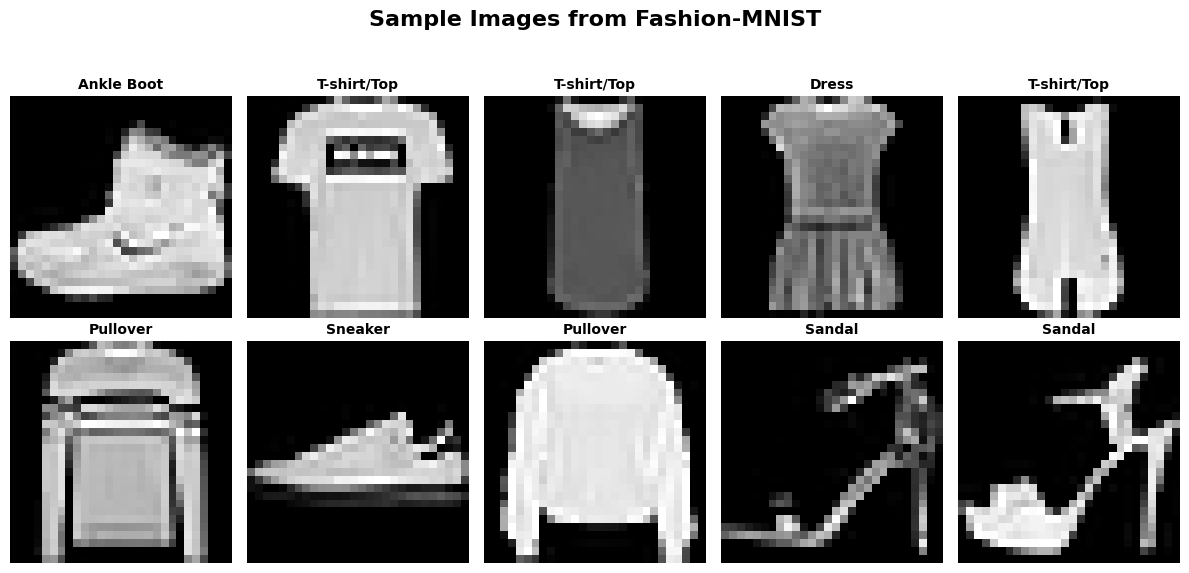

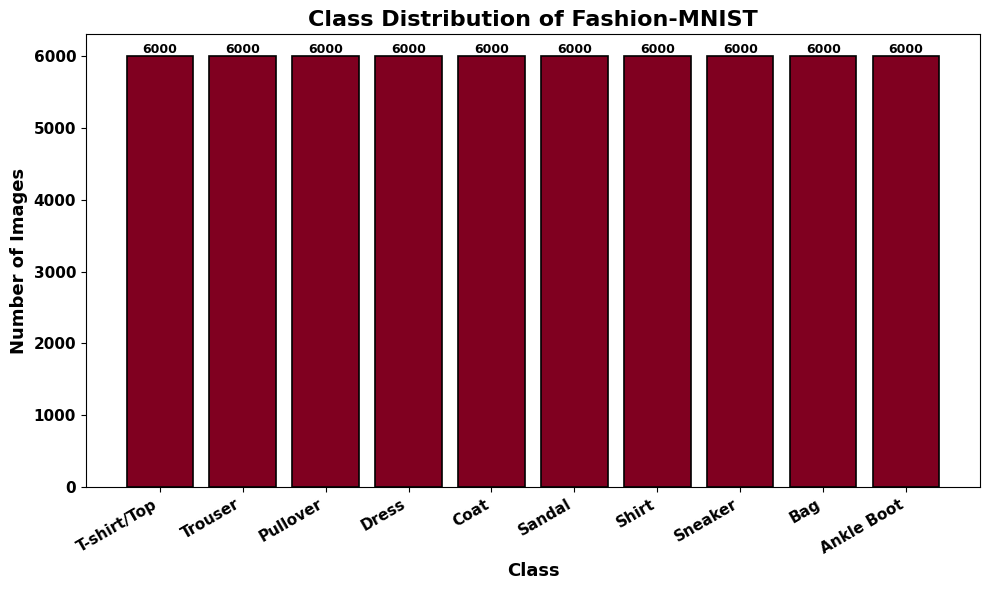


Figures saved successfully.
1. Figures/Figure_1_Sample_Images.eps
2. Figures/Figure_2_Class_Distribution.eps


In [3]:
# ==========================================================
# EXPERIMENT 2 - TASK 1 : DATASET EXPLORATION
# ==========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# ----------------------------------------------------------
# Create folder for saving figures
# ----------------------------------------------------------
FIGURE_DIR = "Figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

# ----------------------------------------------------------
# Load Fashion-MNIST Dataset
# ----------------------------------------------------------
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# ----------------------------------------------------------
# Print Dataset Dimensions
# ----------------------------------------------------------
print("=" * 60)
print("FASHION-MNIST DATASET SUMMARY")
print("=" * 60)

print(f"Training Images Shape : {x_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")
print(f"Testing Images Shape  : {x_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")

print("\nNumber of Training Images :", len(x_train))
print("Number of Testing Images  :", len(x_test))

# ----------------------------------------------------------
# Class Names
# ----------------------------------------------------------
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# ----------------------------------------------------------
# Display 10 Sample Images
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(class_names[y_train[i]], fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Images from Fashion-MNIST",
             fontsize=16,
             fontweight="bold")

plt.tight_layout(rect=[0,0,1,0.95])

sample_path = os.path.join(FIGURE_DIR, "Figure_1_Sample_Images.eps")
plt.savefig(sample_path,
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

# ----------------------------------------------------------
# Plot Class Distribution
# ----------------------------------------------------------
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,6))

bars = plt.bar(
    class_names,
    counts,
    color="#800020",
    edgecolor="black",
    linewidth=1.2
)

plt.title("Class Distribution of Fashion-MNIST",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Class",
           fontsize=13,
           fontweight="bold")

plt.ylabel("Number of Images",
           fontsize=13,
           fontweight="bold")

plt.xticks(rotation=30,
           ha="right",
           fontsize=11,
           fontweight="bold")

plt.yticks(fontsize=11,
           fontweight="bold")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+40,
        str(int(bar.get_height())),
        ha='center',
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()

distribution_path = os.path.join(
    FIGURE_DIR,
    "Figure_2_Class_Distribution.eps"
)

plt.savefig(distribution_path,
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

print("\nFigures saved successfully.")
print(f"1. {sample_path}")
print(f"2. {distribution_path}")

# Task 2: Data Preprocessing

## Objective
To preprocess the Fashion-MNIST dataset by converting the images into a format suitable for training a Multi-Layer Perceptron (MLP).

## Steps Performed
- Flattened each 28 × 28 image into a 784-dimensional feature vector.
- Normalized pixel values from **[0, 255]** to **[0, 1]**.
- Converted class labels into one-hot encoded vectors.
- Verified the tensor shapes before and after preprocessing.

## Outcome
The dataset was successfully preprocessed and transformed into the required format for efficient MLP training.

In [4]:
# ==========================================================
# EXPERIMENT 2 - TASK 2 : DATA PREPROCESSING
# ==========================================================

from tensorflow.keras.utils import to_categorical

print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

# ----------------------------------------------------------
# Shapes Before Preprocessing
# ----------------------------------------------------------
print("\nBefore Preprocessing")
print("-" * 40)

print(f"Training Images Shape : {x_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")
print(f"Testing Images Shape  : {x_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")

# ----------------------------------------------------------
# Flatten Images
# ----------------------------------------------------------
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

# ----------------------------------------------------------
# Normalize Pixel Values
# ----------------------------------------------------------
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

# ----------------------------------------------------------
# One-Hot Encode Labels
# ----------------------------------------------------------
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

# ----------------------------------------------------------
# Shapes After Preprocessing
# ----------------------------------------------------------
print("\nAfter Preprocessing")
print("-" * 40)

print(f"Training Images Shape : {x_train_flat.shape}")
print(f"Training Labels Shape : {y_train_onehot.shape}")
print(f"Testing Images Shape  : {x_test_flat.shape}")
print(f"Testing Labels Shape  : {y_test_onehot.shape}")

# ----------------------------------------------------------
# Verify Pixel Normalization
# ----------------------------------------------------------
print("\nPixel Value Range After Normalization")
print("-" * 40)

print(f"Minimum Pixel Value : {x_train_flat.min():.3f}")
print(f"Maximum Pixel Value : {x_train_flat.max():.3f}")

# ----------------------------------------------------------
# Display One-Hot Encoding Example
# ----------------------------------------------------------
print("\nExample Label Encoding")
print("-" * 40)

print(f"Original Label : {y_train[0]}")
print(f"One-Hot Vector :\n{y_train_onehot[0]}")

print("\nData preprocessing completed successfully.")

DATA PREPROCESSING

Before Preprocessing
----------------------------------------
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)

After Preprocessing
----------------------------------------
Training Images Shape : (60000, 784)
Training Labels Shape : (60000, 10)
Testing Images Shape  : (10000, 784)
Testing Labels Shape  : (10000, 10)

Pixel Value Range After Normalization
----------------------------------------
Minimum Pixel Value : 0.000
Maximum Pixel Value : 1.000

Example Label Encoding
----------------------------------------
Original Label : 9
One-Hot Vector :
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

Data preprocessing completed successfully.


# Task 3: Model Construction

## Objective
To construct a Multi-Layer Perceptron (MLP) model for multi-class image classification using TensorFlow/Keras.

## Model Architecture
- **Input Layer:** 784 neurons
- **Hidden Layer 1:** 128 neurons with ReLU activation
- **Hidden Layer 2:** 64 neurons with ReLU activation
- **Output Layer:** 10 neurons with Softmax activation

## Steps Performed
- Built the MLP using TensorFlow/Keras.
- Added two hidden layers with ReLU activation.
- Added a Softmax output layer for multi-class classification.
- Displayed the model architecture using `model.summary()`.

## Outcome
The MLP model was successfully constructed and is ready for training on the preprocessed Fashion-MNIST dataset.

In [5]:
# ==========================================================
# EXPERIMENT 2 - TASK 3 : MODEL CONSTRUCTION
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("=" * 60)
print("MODEL CONSTRUCTION")
print("=" * 60)

# ----------------------------------------------------------
# Build the Multi-Layer Perceptron (MLP)
# ----------------------------------------------------------
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,), name="Hidden_Layer_1"),
    Dense(64, activation="relu", name="Hidden_Layer_2"),
    Dense(10, activation="softmax", name="Output_Layer")
])

# ----------------------------------------------------------
# Display Model Summary
# ----------------------------------------------------------
print("\nModel Architecture\n")
model.summary()

print("\nModel constructed successfully.")

MODEL CONSTRUCTION


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Architecture



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Model constructed successfully.


# Task 4: Model Training

## Objective
To train the constructed MLP model using the preprocessed Fashion-MNIST dataset.

## Training Configuration
- **Optimizer:** Adam
- **Loss Function:** Categorical Cross-Entropy
- **Evaluation Metric:** Accuracy
- **Epochs:** 20
- **Batch Size:** 32

## Steps Performed
- Compiled the MLP model using the Adam optimizer and categorical cross-entropy loss.
- Trained the model for 20 epochs with a batch size of 32.
- Recorded the training and validation accuracy and loss at each epoch.

## Outcome
The MLP model was successfully trained, and the training history was obtained for further performance evaluation and visualization.

MODEL TRAINING
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8164 - loss: 0.5159 - val_accuracy: 0.8512 - val_loss: 0.4114
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8637 - loss: 0.3791 - val_accuracy: 0.8707 - val_loss: 0.3545
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8739 - loss: 0.3402 - val_accuracy: 0.8739 - val_loss: 0.3465
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8834 - loss: 0.3182 - val_accuracy: 0.8776 - val_loss: 0.3371
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8887 - loss: 0.2965 - val_accuracy: 0.8650 - val_loss: 0.3693
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8963 - loss: 0.2825 - val_accuracy: 0.8687 - val_loss: 0.3697
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8986 - loss: 0.2704 - val_accuracy: 0.8787 - val_loss: 0.3396
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9030 - 

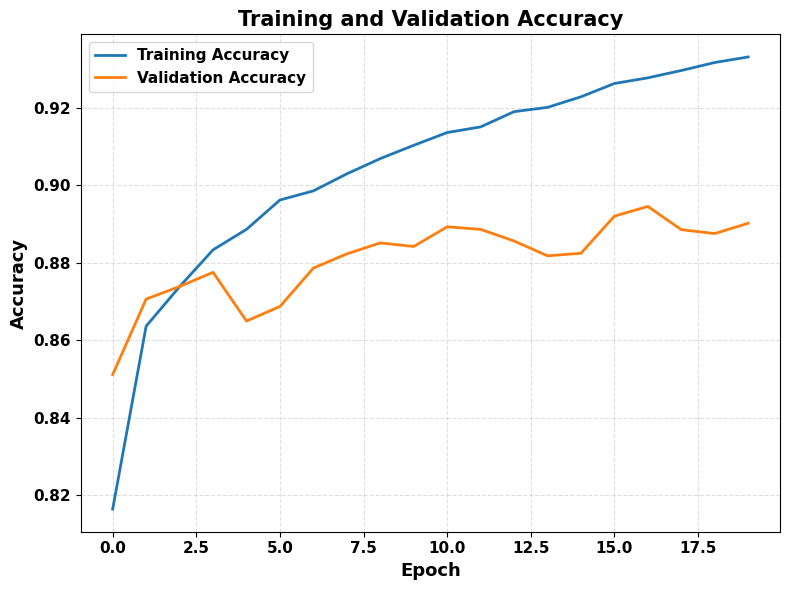

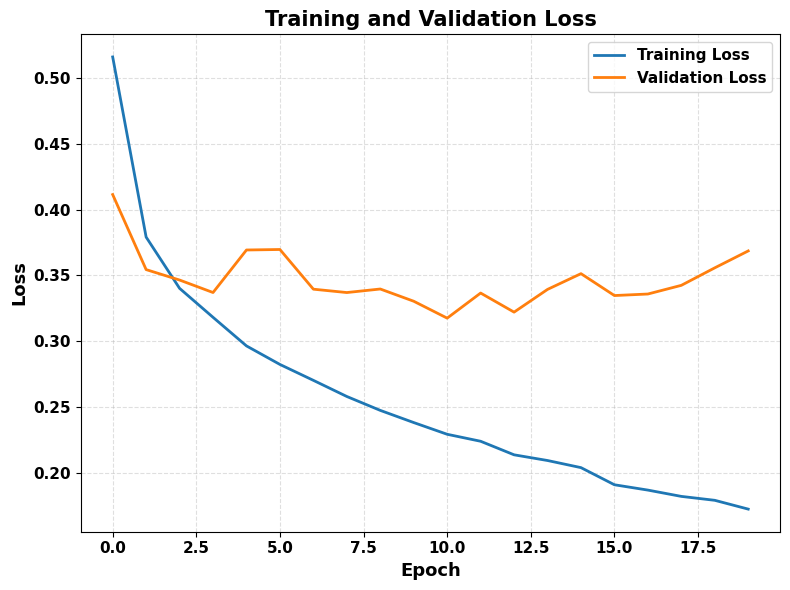


Figures saved successfully.
Figure_3_Training_Validation_Accuracy.eps
Figure_4_Training_Validation_Loss.eps


In [6]:
# ==========================================================
# EXPERIMENT 2 - TASK 4 : MODEL TRAINING
# ==========================================================

import time
import matplotlib.pyplot as plt

print("=" * 60)
print("MODEL TRAINING")
print("=" * 60)

# ----------------------------------------------------------
# Compile the Model
# ----------------------------------------------------------
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------------------------------------
# Train the Model
# ----------------------------------------------------------
start_time = time.time()

history = model.fit(
    x_train_flat,
    y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\nTraining Time: {training_time:.2f} seconds")

# ==========================================================
# Plot 1 : Training & Validation Accuracy
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(history.history['accuracy'],
         linewidth=2,
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         linewidth=2,
         label='Validation Accuracy')

plt.title("Training and Validation Accuracy",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Epoch",
           fontsize=13,
           fontweight='bold')

plt.ylabel("Accuracy",
           fontsize=13,
           fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.legend(prop={'weight':'bold','size':11})

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_3_Training_Validation_Accuracy.eps"),
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

# ==========================================================
# Plot 2 : Training & Validation Loss
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(history.history['loss'],
         linewidth=2,
         label='Training Loss')

plt.plot(history.history['val_loss'],
         linewidth=2,
         label='Validation Loss')

plt.title("Training and Validation Loss",
          fontsize=15,
          fontweight='bold')

plt.xlabel("Epoch",
           fontsize=13,
           fontweight='bold')

plt.ylabel("Loss",
           fontsize=13,
           fontweight='bold')

plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.legend(prop={'weight':'bold','size':11})

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_4_Training_Validation_Loss.eps"),
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("\nFigures saved successfully.")
print("Figure_3_Training_Validation_Accuracy.eps")
print("Figure_4_Training_Validation_Loss.eps")

# Task 5: Model Evaluation

## Objective
To evaluate the performance of the trained MLP model on the testing dataset using various classification metrics.

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

## Steps Performed
- Predicted the class labels for the testing dataset.
- Computed the classification metrics.
- Generated the confusion matrix and classification report to analyze the model's performance.

## Outcome
The trained MLP model was successfully evaluated, and its performance was assessed using multiple evaluation metrics for multi-class image classification.

MODEL EVALUATION
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Accuracy : 0.8873
Precision: 0.8884
Recall   : 0.8873
F1-Score : 0.8867

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 T-shirt/Top     0.8570    0.8330    0.8448      1000
     Trouser     0.9810    0.9810    0.9810      1000
    Pullover     0.7459    0.8630    0.8002      1000
       Dress     0.9081    0.8890    0.8984      1000
        Coat     0.7846    0.8340    0.8085      1000
      Sandal     0.9854    0.9440    0.9642      1000
       Shirt     0.7571    0.6360    0.6913      1000
     Sneaker     0.9465    0.9560    0.9512      1000
         Bag     0.9827    0.9660    0.9743      1000
  Ankle Boot     0.9355    0.9710    0.9529      1000

    accuracy                         0.8873     10000
   macro avg     0.8884    0.8873    0.8867     10000
weighted avg     0.8884    0.8873    0.8867     10000



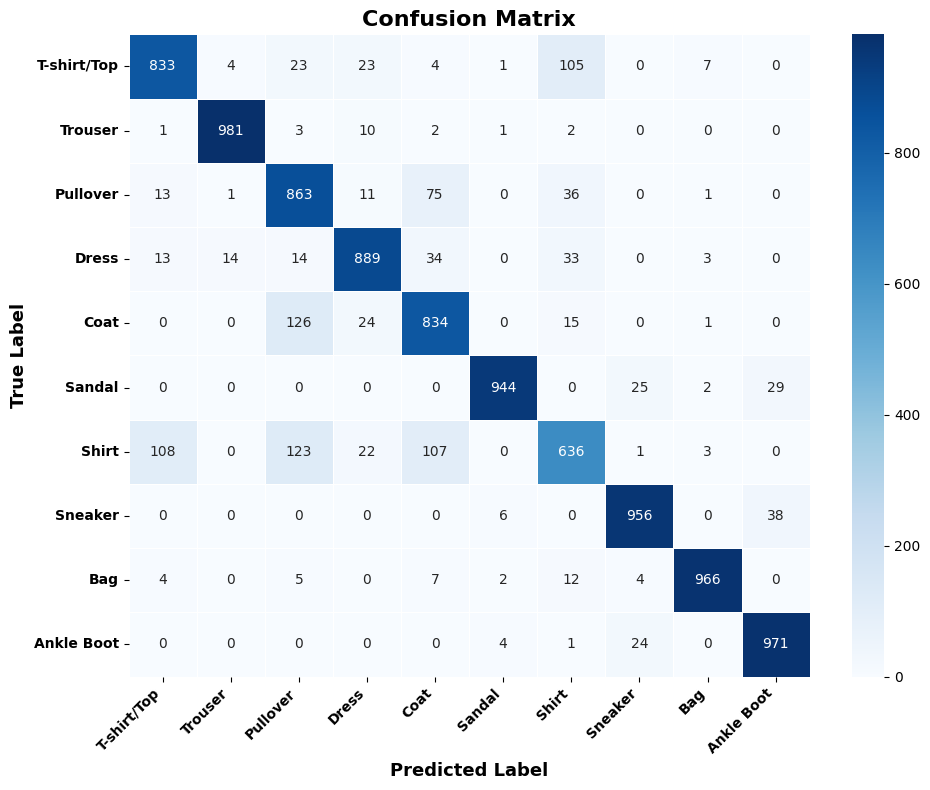


Confusion Matrix saved successfully.
Figure_5_Confusion_Matrix.eps


In [7]:
# ==========================================================
# EXPERIMENT 2 - TASK 5 : MODEL EVALUATION
# ==========================================================

import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

# ----------------------------------------------------------
# Predict on Test Data
# ----------------------------------------------------------
y_pred_prob = model.predict(x_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = np.argmax(y_test_onehot, axis=1)

# ----------------------------------------------------------
# Performance Metrics
# ----------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar=True
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_5_Confusion_Matrix.eps"),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nConfusion Matrix saved successfully.")
print("Figure_5_Confusion_Matrix.eps")

# Hyperparameter Optimization - Task 1: Build Baseline MLP Model

## Objective
To build a baseline Multi-Layer Perceptron (MLP) model that serves as a reference for hyperparameter optimization.

## Steps Performed
- Defined a configurable MLP model using TensorFlow/Keras.
- Included adjustable hyperparameters such as hidden layers, hidden neurons, learning rate, optimizer, activation function, and dropout rate.
- Compiled the model using categorical cross-entropy loss and accuracy as the evaluation metric.

## Outcome
A baseline MLP model was successfully created and will be used for automated hyperparameter optimization.

In [8]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 1
# Build Baseline MLP Model
# ==========================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

print("=" * 60)
print("BASELINE MLP MODEL FOR HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

# ----------------------------------------------------------
# Model Building Function
# ----------------------------------------------------------
def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):
    """
    Creates and compiles an MLP model with the given hyperparameters.
    """

    model = Sequential()

    # ------------------------------------------------------
    # Input Layer
    # ------------------------------------------------------
    model.add(Input(shape=(784,)))

    # ------------------------------------------------------
    # First Hidden Layer
    # ------------------------------------------------------
    model.add(Dense(
        units=hidden_neurons,
        activation=activation
    ))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    # ------------------------------------------------------
    # Additional Hidden Layers
    # ------------------------------------------------------
    for _ in range(hidden_layers - 1):
        model.add(Dense(
            units=hidden_neurons,
            activation=activation
        ))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    # ------------------------------------------------------
    # Output Layer
    # ------------------------------------------------------
    model.add(Dense(
        units=10,
        activation="softmax"
    ))

    # ------------------------------------------------------
    # Optimizer Selection
    # ------------------------------------------------------
    optimizer = optimizer.lower()

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)

    elif optimizer == "rmsprop":
        opt = RMSprop(learning_rate=learning_rate)

    else:
        raise ValueError(f"Unsupported optimizer: {optimizer}")

    # ------------------------------------------------------
    # Compile Model
    # ------------------------------------------------------
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ----------------------------------------------------------
# Build Baseline Model
# ----------------------------------------------------------
baseline_model = create_model()

print("\nBaseline model created successfully.\n")

baseline_model.summary()

BASELINE MLP MODEL FOR HYPERPARAMETER OPTIMIZATION

Baseline model created successfully.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

# Hyperparameter Optimization - Task 2: Define Hyperparameter Search Space

## Objective
To define the range of hyperparameter values that will be explored during automated hyperparameter optimization.

## Hyperparameters
- Hidden Layers
- Hidden Neurons
- Learning Rate
- Batch Size
- Epochs
- Optimizer
- Activation Function
- Dropout Rate

## Steps Performed
- Specified candidate values for each hyperparameter.
- Created the search space dictionary to be used by RandomizedSearchCV.

## Outcome
The hyperparameter search space was successfully defined for automated model tuning.

In [9]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 2
# Define Hyperparameter Search Space
# ==========================================================

print("=" * 60)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 60)

# ----------------------------------------------------------
# Define Search Space
# ----------------------------------------------------------
param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

# ----------------------------------------------------------
# Display Search Space
# ----------------------------------------------------------
print("\nCandidate Hyperparameter Values:\n")

for parameter, values in param_dist.items():
    print(f"{parameter:<28}: {values}")

print("\nHyperparameter search space defined successfully.")

HYPERPARAMETER SEARCH SPACE

Candidate Hyperparameter Values:

model__hidden_layers        : [1, 2, 3]
model__hidden_neurons       : [32, 64, 128, 256]
model__learning_rate        : [0.1, 0.01, 0.001]
model__optimizer            : ['sgd', 'adam', 'rmsprop']
model__activation           : ['relu', 'tanh', 'sigmoid']
model__dropout_rate         : [0.0, 0.2, 0.5]
batch_size                  : [16, 32, 64, 128]
epochs                      : [10, 20, 30]

Hyperparameter search space defined successfully.


# Hyperparameter Optimization - Task 3: Randomized Search with 5-Fold Cross-Validation

## Objective
To identify the optimal hyperparameter combination using RandomizedSearchCV with 5-fold cross-validation.

## Steps Performed
- Wrapped the Keras model using the SciKeras `KerasClassifier`.
- Configured RandomizedSearchCV with the defined hyperparameter search space.
- Performed 5-fold stratified cross-validation to evaluate multiple randomly selected hyperparameter combinations.
- Recorded the average cross-validation accuracy for each combination.

## Outcome
The best-performing hyperparameter combination was identified based on the highest cross-validation accuracy.

In [10]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 3
# Randomized Search with 5-Fold Cross Validation
# ==========================================================

# Install SciKeras if not already installed
try:
    from scikeras.wrappers import KerasClassifier
except ImportError:
    !pip install -q scikeras
    from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import time

print("=" * 60)
print("RANDOMIZED SEARCH WITH 5-FOLD CROSS VALIDATION")
print("=" * 60)

# ----------------------------------------------------------
# Wrap the Keras Model
# ----------------------------------------------------------
keras_model = KerasClassifier(
    model=create_model,
    verbose=0
)

# ----------------------------------------------------------
# Stratified 5-Fold Cross Validation
# ----------------------------------------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ----------------------------------------------------------
# Randomized Search
# ----------------------------------------------------------
random_search = RandomizedSearchCV(
    estimator=keras_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring="accuracy",
    random_state=42,
    n_jobs=1,
    verbose=2,
    error_score="raise"
)

# ----------------------------------------------------------
# Perform Hyperparameter Optimization
# ----------------------------------------------------------
print("\nStarting Randomized Search...\n")

search_start = time.time()

random_search.fit(
    x_train_flat,
    y_train
)

search_end = time.time()

optimization_time = search_end - search_start

print("\nRandomized Search Completed Successfully!")
print(f"Total Optimization Time : {optimization_time:.2f} seconds")

RANDOMIZED SEARCH WITH 5-FOLD CROSS VALIDATION

Starting Randomized Search...

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  41.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  40.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  40.8s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer=adam; total time=  40.4s
[CV] END batch_size=64, epochs=20, model

# Hyperparameter Optimization - Task 4: Record Best Hyperparameter Combination

## Objective
To identify the best hyperparameter combination obtained from RandomizedSearchCV based on cross-validation performance.

## Steps Performed
- Retrieved the best hyperparameter values from the completed Randomized Search.
- Recorded the corresponding cross-validation accuracy.

## Outcome
The optimal hyperparameter combination was successfully identified and selected for retraining the final MLP model.

In [11]:
print(random_search.best_params_)
print(random_search.best_score_)

{'model__optimizer': 'adam', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 2, 'model__dropout_rate': 0.0, 'model__activation': 'sigmoid', 'epochs': 30, 'batch_size': 32}
0.8975166666666666


In [12]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 4
# Record Best Hyperparameter Combination
# ==========================================================

print("=" * 60)
print("BEST HYPERPARAMETER COMBINATION")
print("=" * 60)

print("\nBest Hyperparameters:\n")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter:<30}: {value}")

print(f"\nBest Cross-Validation Accuracy : {random_search.best_score_:.4f}")

best_params = random_search.best_params_

BEST HYPERPARAMETER COMBINATION

Best Hyperparameters:

model__optimizer              : adam
model__learning_rate          : 0.001
model__hidden_neurons         : 256
model__hidden_layers          : 2
model__dropout_rate           : 0.0
model__activation             : sigmoid
epochs                        : 30
batch_size                    : 32

Best Cross-Validation Accuracy : 0.8975


# Hyperparameter Optimization - Task 5: Retrain the Optimized Model

## Objective
To retrain the MLP model using the optimal hyperparameters obtained from RandomizedSearchCV.

## Steps Performed
- Constructed a new MLP model using the best hyperparameter combination.
- Retrained the model on the preprocessed training dataset.
- Recorded the training and validation performance over all epochs.

## Outcome
The optimized MLP model was successfully retrained and is ready for evaluation on the testing dataset.

In [13]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 5
# Retrain Model Using the Best Hyperparameters
# ==========================================================

print("=" * 60)
print("RETRAINING MODEL WITH BEST HYPERPARAMETERS")
print("=" * 60)

# ----------------------------------------------------------
# Build Optimized Model
# ----------------------------------------------------------
optimized_model = create_model(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer=best_params["model__optimizer"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"]
)

print("\nOptimized Model Architecture:\n")
optimized_model.summary()

# ----------------------------------------------------------
# Retrain the Optimized Model
# ----------------------------------------------------------
history_optimized = optimized_model.fit(
    x_train_flat,
    y_train,                    # <-- Changed from y_train_onehot
    validation_split=0.20,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)

print("\n" + "=" * 60)
print("OPTIMIZED MODEL TRAINING COMPLETED")
print("=" * 60)

print("\nBest Hyperparameters Used:")
print(f"Hidden Layers   : {best_params['model__hidden_layers']}")
print(f"Hidden Neurons  : {best_params['model__hidden_neurons']}")
print(f"Learning Rate   : {best_params['model__learning_rate']}")
print(f"Optimizer       : {best_params['model__optimizer']}")
print(f"Activation      : {best_params['model__activation']}")
print(f"Dropout Rate    : {best_params['model__dropout_rate']}")
print(f"Epochs          : {best_params['epochs']}")
print(f"Batch Size      : {best_params['batch_size']}")

RETRAINING MODEL WITH BEST HYPERPARAMETERS

Optimized Model Architecture:



Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_146 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_147 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_148 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,322 (1.03 MB)

 Trainable params: 269,322 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7954 - loss: 0.5693 - val_accuracy: 0.8510 - val_loss: 0.4106
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8567 - loss: 0.3944 - val_accuracy: 0.8612 - val_loss: 0.3899
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8695 - loss: 0.3560 - val_accuracy: 0.8715 - val_loss: 0.3482
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8786 - loss: 0.3287 - val_accuracy: 0.8754 - val_loss: 0.3367
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8859 - loss: 0.3085 - val_accuracy: 0.8763 - val_loss: 0.3386
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8918 - loss: 0.2910 - val_accuracy: 0.8841 - val_loss: 0.3197
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8984 - loss: 0.2744 - val_accuracy: 0.8654 - val_loss: 0.3513
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9007 - loss: 0.2627 - 

# Hyperparameter Optimization - Task 6: Evaluate the Optimized Model

## Objective
To evaluate the performance of the optimized MLP model on the testing dataset using multiple classification metrics.

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

## Steps Performed
- Predicted the class labels for the testing dataset.
- Computed the evaluation metrics.
- Generated the confusion matrix and classification report.

## Outcome
The optimized model was successfully evaluated, and its performance was assessed using multiple classification metrics.

EVALUATION OF OPTIMIZED MODEL
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Accuracy  : 0.8902
Precision : 0.8933
Recall    : 0.8902
F1-Score  : 0.8910

Classification Report:

              precision    recall  f1-score   support

 T-shirt/Top       0.88      0.77      0.82      1000
     Trouser       0.97      0.99      0.98      1000
    Pullover       0.81      0.82      0.82      1000
       Dress       0.90      0.88      0.89      1000
        Coat       0.82      0.83      0.83      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.68      0.77      0.72      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.99      0.96      0.97      1000
  Ankle Boot       0.95      0.97      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



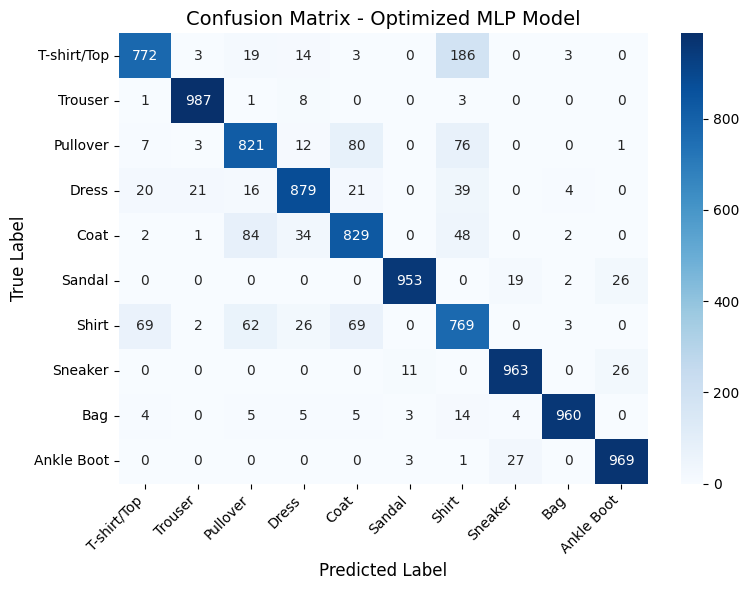

In [19]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 6
# Evaluate the Optimized Model
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("=" * 60)
print("EVALUATION OF OPTIMIZED MODEL")
print("=" * 60)

# ----------------------------------------------------------
# Predict Test Data
# ----------------------------------------------------------
y_pred_prob = optimized_model.predict(x_test_flat)
y_pred = np.argmax(y_pred_prob, axis=1)

# ----------------------------------------------------------
# Compute Evaluation Metrics
# ----------------------------------------------------------
optimized_accuracy = accuracy_score(y_test, y_pred)

optimized_precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------
optimized_cm = confusion_matrix(y_test, y_pred)

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------
optimized_report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------
print(f"\nAccuracy  : {optimized_accuracy:.4f}")
print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1-Score  : {optimized_f1:.4f}")

print("\nClassification Report:\n")
print(optimized_report)

# ----------------------------------------------------------
# Plot Confusion Matrix
# ----------------------------------------------------------
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    optimized_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    alpha=1
)

plt.title("Confusion Matrix - Optimized MLP Model", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/optimized_confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# Hyperparameter Optimization - Task 7: Compare Baseline and Optimized Models

## Objective
To compare the performance of the baseline MLP model with the optimized MLP model after hyperparameter tuning.

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score

## Steps Performed
- Collected the evaluation metrics of both models.
- Created a comparison table.
- Visualized the comparison using a bar chart.
- Saved the figure in EPS format with 600 DPI for publication-quality output.

## Outcome
The optimized model was compared with the baseline model to analyze the improvement achieved through hyperparameter optimization.

COMPARISON OF BASELINE AND OPTIMIZED MODEL

Comparison Table

      Metric  Baseline Model  Optimized Model
0   Accuracy        0.887300         0.890200
1  Precision        0.888375         0.893310
2     Recall        0.887300         0.890200
3   F1-Score        0.886695         0.891019


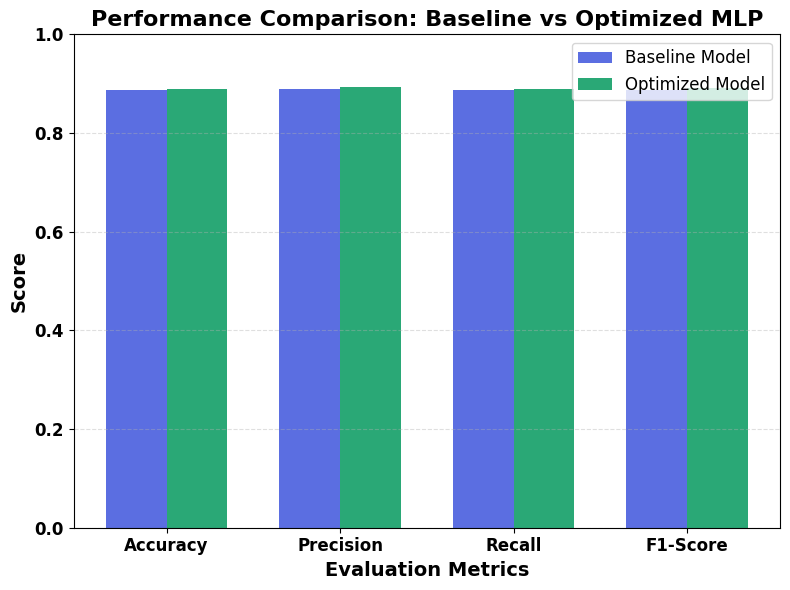


Figure saved successfully.
Figure_6_Baseline_vs_Optimized.eps


In [15]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 7
# Compare Baseline and Optimized Models
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("COMPARISON OF BASELINE AND OPTIMIZED MODEL")
print("=" * 60)

# ----------------------------------------------------------
# Comparison Table
# ----------------------------------------------------------
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Baseline Model": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Optimized Model": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]
})

print("\nComparison Table\n")
print(comparison_df)

# ----------------------------------------------------------
# Performance Comparison Chart
# ----------------------------------------------------------
plt.figure(figsize=(8,6))

x = np.arange(len(comparison_df["Metric"]))
width = 0.35

plt.bar(
    x - width/2,
    comparison_df["Baseline Model"],
    width,
    label="Baseline Model",
    color="#5B6EE1"
)

plt.bar(
    x + width/2,
    comparison_df["Optimized Model"],
    width,
    label="Optimized Model",
    color="#2AA876"
)

plt.xticks(
    x,
    comparison_df["Metric"],
    fontsize=12,
    fontweight="bold"
)

plt.yticks(
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "Evaluation Metrics",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Score",
    fontsize=14,
    fontweight="bold"
)

plt.title(
    "Performance Comparison: Baseline vs Optimized MLP",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0, 1.0)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(
    fontsize=12
)

plt.tight_layout()

# ----------------------------------------------------------
# Save Figure
# ----------------------------------------------------------
plt.savefig(
    os.path.join(FIGURE_DIR, "Figure_6_Baseline_vs_Optimized.eps"),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print("Figure_6_Baseline_vs_Optimized.eps")

HYPERPARAMETER SEARCH RESULTS


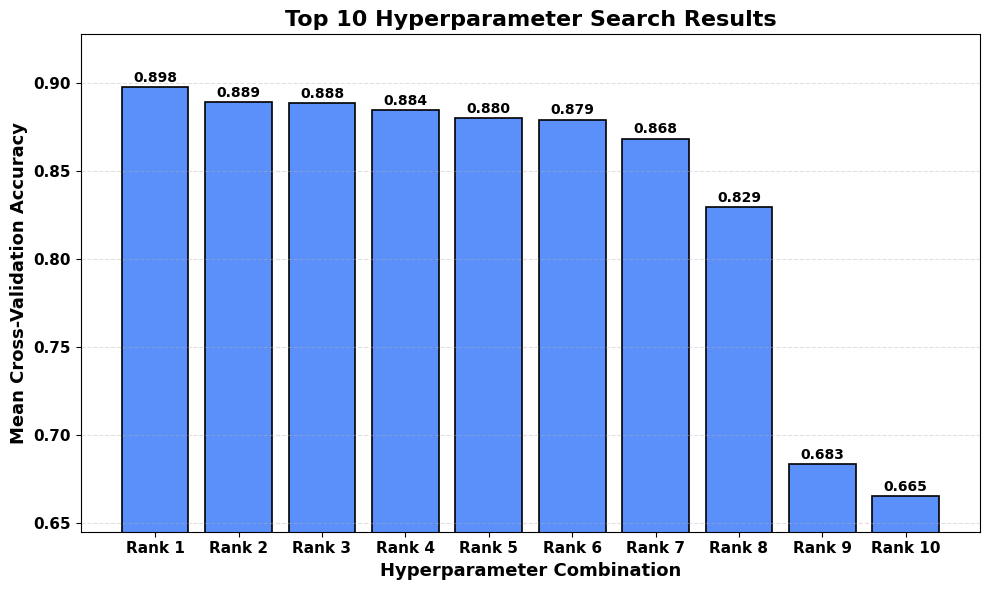


Figure saved successfully.
Figure_7_Hyperparameter_Search_Results.eps


In [16]:
# ==========================================================
# HYPERPARAMETER OPTIMIZATION - TASK 8
# Hyperparameter Search Results
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("=" * 60)
print("HYPERPARAMETER SEARCH RESULTS")
print("=" * 60)

# ----------------------------------------------------------
# Convert CV Results to DataFrame
# ----------------------------------------------------------
results = pd.DataFrame(random_search.cv_results_)

# ----------------------------------------------------------
# Select Top 10 Hyperparameter Combinations
# ----------------------------------------------------------
top_results = results.sort_values(
    by="mean_test_score",
    ascending=False
).head(10)

top_results = top_results.reset_index(drop=True)

# ----------------------------------------------------------
# Create Labels
# ----------------------------------------------------------
labels = [
    f"Rank {i+1}"
    for i in range(len(top_results))
]

scores = top_results["mean_test_score"]

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
plt.figure(figsize=(10,6))

bars = plt.bar(
    labels,
    scores,
    color="#5B8FF9",          # Elegant Royal Blue
    edgecolor="black",
    linewidth=1.2
)

# ----------------------------------------------------------
# Display Accuracy Values
# ----------------------------------------------------------
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.3f}",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
plt.title(
    "Top 10 Hyperparameter Search Results",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Hyperparameter Combination",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Mean Cross-Validation Accuracy",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    fontsize=11,
    fontweight="bold"
)

plt.ylim(
    scores.min()-0.02,
    min(1.0, scores.max()+0.03)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

# ----------------------------------------------------------
# Save Figure
# ----------------------------------------------------------
plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure_7_Hyperparameter_Search_Results.eps"
    ),
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved successfully.")
print("Figure_7_Hyperparameter_Search_Results.eps")

In [17]:
# ==========================================================
# RESULTS
# ==========================================================

import pandas as pd

print("=" * 70)
print("RESULTS")
print("=" * 70)

# ----------------------------------------------------------
# Best Hyperparameters
# ----------------------------------------------------------
best_hyperparameters = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout",
        "Cross-validation Accuracy",
        "Testing Accuracy"
    ],
    "Best Value": [
        best_params["model__hidden_layers"],
        best_params["model__hidden_neurons"],
        best_params["model__learning_rate"],
        best_params["batch_size"],
        best_params["model__optimizer"].upper(),
        best_params["model__activation"].capitalize(),
        best_params["epochs"],
        best_params["model__dropout_rate"],
        f"{random_search.best_score_:.4f}",
        f"{optimized_accuracy:.4f}"
    ]
})

print("\nBEST HYPERPARAMETERS\n")
print(best_hyperparameters.to_string(index=False))

# ----------------------------------------------------------
# Performance Comparison
# ----------------------------------------------------------
performance_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Baseline": [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}"
    ],
    "Optimized": [
        f"{optimized_accuracy:.4f}",
        f"{optimized_precision:.4f}",
        f"{optimized_recall:.4f}",
        f"{optimized_f1:.4f}"
    ]
})

print("\n" + "=" * 70)
print("PERFORMANCE COMPARISON\n")
print(performance_comparison.to_string(index=False))

# ----------------------------------------------------------
# Training Time
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("TRAINING TIME")
print("=" * 70)

print(f"Hyperparameter Optimization Time : {optimization_time:.2f} seconds")

RESULTS

BEST HYPERPARAMETERS

           Hyperparameter Best Value
            Hidden Layers          2
           Hidden Neurons        256
            Learning Rate      0.001
               Batch Size         32
                Optimizer       ADAM
      Activation Function    Sigmoid
                   Epochs         30
                  Dropout        0.0
Cross-validation Accuracy     0.8975
         Testing Accuracy     0.8902

PERFORMANCE COMPARISON

   Metric Baseline Optimized
 Accuracy   0.8873    0.8902
Precision   0.8884    0.8933
   Recall   0.8873    0.8902
 F1-Score   0.8867    0.8910

TRAINING TIME
Hyperparameter Optimization Time : 4135.68 seconds
